# Sprint 26 — Plots de présentation
## Board NUCLEO-F439ZI : Régression RUL + Multi-classe + Chiffres finaux

**Expériences couvertes** : `exp_S26_01` (EWC Reg CMAPSS), `exp_S26_02` (EWC Multi-class CWRU), `exp_S26_03` (footprint firmware)

**Contenu** :
- PC vs Board RMSE (avec ratio annoté)
- Latency breakdown par mode (regression / classification / multi-class)
- RAM breakdown firmware par composant
- F1 progressif par tâche CWRU board
- Checklist visuelle Gap 1 / Gap 2 / Gap 3

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint26"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

def load(exp_id):
    with open(EXP / exp_id / "results.json") as f:
        return json.load(f)

s26_01 = load("exp_S26_01")  # EWC Regression CMAPSS
s26_02 = load("exp_S26_02")  # EWC Multi-class CWRU
s26_03 = load("exp_S26_03")  # Firmware footprint

print("Données chargées ✅")
print(f"  S26_01 : RMSE_board={s26_01['rmse_board']:.2f}, latency={s26_01['latency_p50_us']} µs")
print(f"  S26_02 : F1_macro={s26_02['f1_macro_board']:.3f}, latency={s26_02['latency_p50_us']} µs")
print(f"  S26_03 : firmware .bss={s26_03['total_firmware_bss_bytes']:,} B")

Données chargées ✅
  S26_01 : RMSE_board=21.15, latency=233 µs
  S26_02 : F1_macro=0.729, latency=403 µs
  S26_03 : firmware .bss=66,748 B


## 1. PC vs Board — RMSE comparaison (Régression RUL CMAPSS)

/tmp/ipykernel_13051/3128086473.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13051/3128086473.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "pc_vs_board_rmse.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


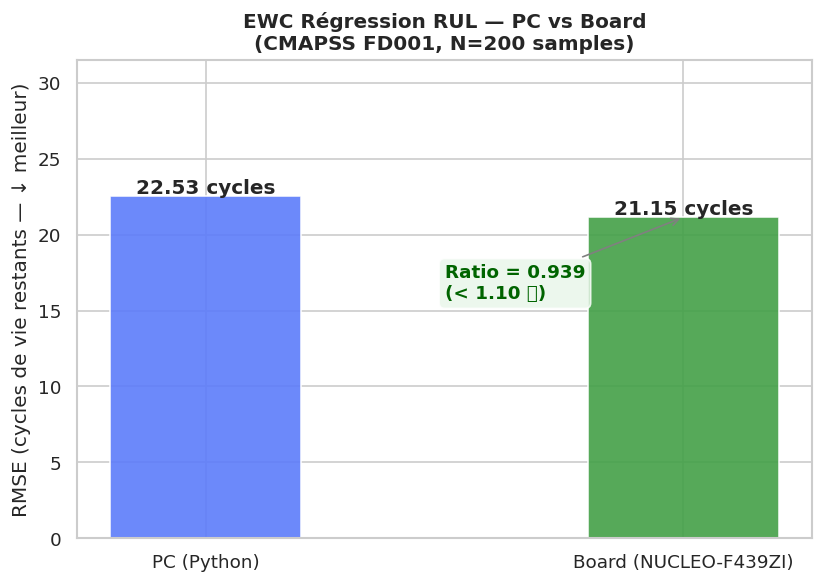

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))

rmse_vals = [s26_01["rmse_pc"], s26_01["rmse_board"]]
labels    = ["PC (Python)", "Board (NUCLEO-F439ZI)"]
colors    = ["#5C7CFA", "#43A047"]

bars = ax.bar(labels, rmse_vals, color=colors, width=0.4, edgecolor="white", alpha=0.9)
for bar, v in zip(bars, rmse_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.2f} cycles",
            ha="center", fontsize=12, fontweight="bold")

ratio = s26_01["rmse_ratio_board_over_pc"]
ax.annotate(
    f"Ratio = {ratio:.3f}\n(< 1.10 ✅)",
    xy=(1, s26_01["rmse_board"]),
    xytext=(0.5, max(rmse_vals) * 0.7),
    textcoords="data",
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=11, color="darkgreen", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", alpha=0.8)
)

ax.set_ylabel("RMSE (cycles de vie restants — ↓ meilleur)")
ax.set_title("EWC Régression RUL — PC vs Board\n(CMAPSS FD001, N=200 samples)",
             fontweight="bold")
ax.set_ylim(0, max(rmse_vals) * 1.4)

plt.tight_layout()
plt.savefig(FIG_DIR / "pc_vs_board_rmse.png", bbox_inches="tight")
plt.show()

## 2. Latency breakdown — Comparaison des 3 modes board

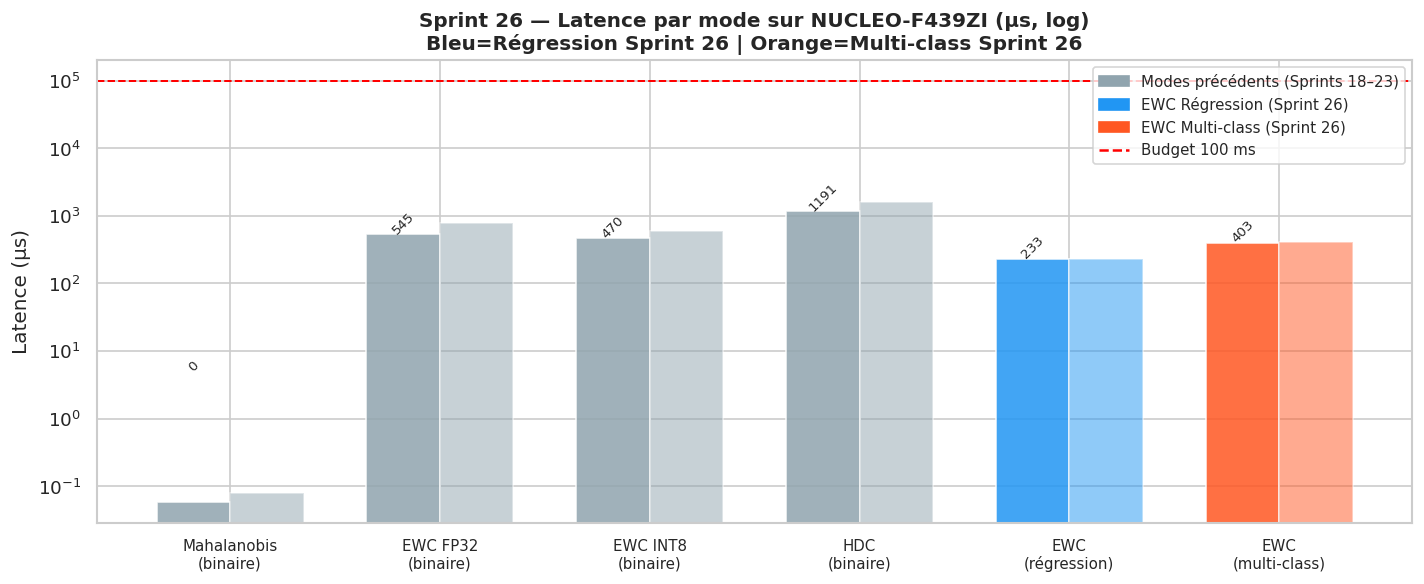

In [3]:
# Latences mesurées sur NUCLEO-F439ZI
modes = [
    "Mahalanobis\n(binaire)",
    "EWC FP32\n(binaire)",
    "EWC INT8\n(binaire)",
    "HDC\n(binaire)",
    "EWC\n(régression)",
    "EWC\n(multi-class)",
]
lat_p50 = [0.059, 545, 470, 1191, 233, 403]  # µs
lat_p99 = [0.079, 796, 600, 1594, 233, 404]  # µs

# Injecter les valeurs S26 mesurées
lat_p50[-2] = s26_01["latency_p50_us"]
lat_p99[-2] = s26_01["latency_p99_us"]
lat_p50[-1] = s26_02["latency_p50_us"]
lat_p99[-1] = s26_02["latency_p99_us"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(modes))
w = 0.35

colors_new = ["#90A4AE", "#90A4AE", "#90A4AE", "#90A4AE", "#2196F3", "#FF5722"]

b1 = ax.bar(x - w/2, lat_p50, w, label="P50", color=colors_new, alpha=0.85, edgecolor="white")
b2 = ax.bar(x + w/2, lat_p99, w, label="P99", color=colors_new, alpha=0.5, edgecolor="white")

for bar, v in zip(b1, lat_p50):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, f"{v:.0f}",
            ha="center", fontsize=8, rotation=45)

ax.axhline(100_000, color="red", linestyle="--", linewidth=1.2,
           label="Budget latence Gap 2 (100 ms)")
ax.set_xticks(x)
ax.set_xticklabels(modes, fontsize=9)
ax.set_ylabel("Latence (µs)")
ax.set_yscale("log")
ax.set_title("Sprint 26 — Latence par mode sur NUCLEO-F439ZI (µs, log)\n"
             "Bleu=Régression Sprint 26 | Orange=Multi-class Sprint 26",
             fontweight="bold")

from matplotlib.patches import Patch
legend = [
    Patch(color="#90A4AE", label="Modes précédents (Sprints 18–23)"),
    Patch(color="#2196F3", label="EWC Régression (Sprint 26)"),
    Patch(color="#FF5722", label="EWC Multi-class (Sprint 26)"),
    plt.Line2D([0],[0], color="red", linestyle="--", label="Budget 100 ms"),
]
ax.legend(handles=legend, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "latency_breakdown_all_modes.png", bbox_inches="tight")
plt.show()

## 3. RAM breakdown firmware — .bss par composant

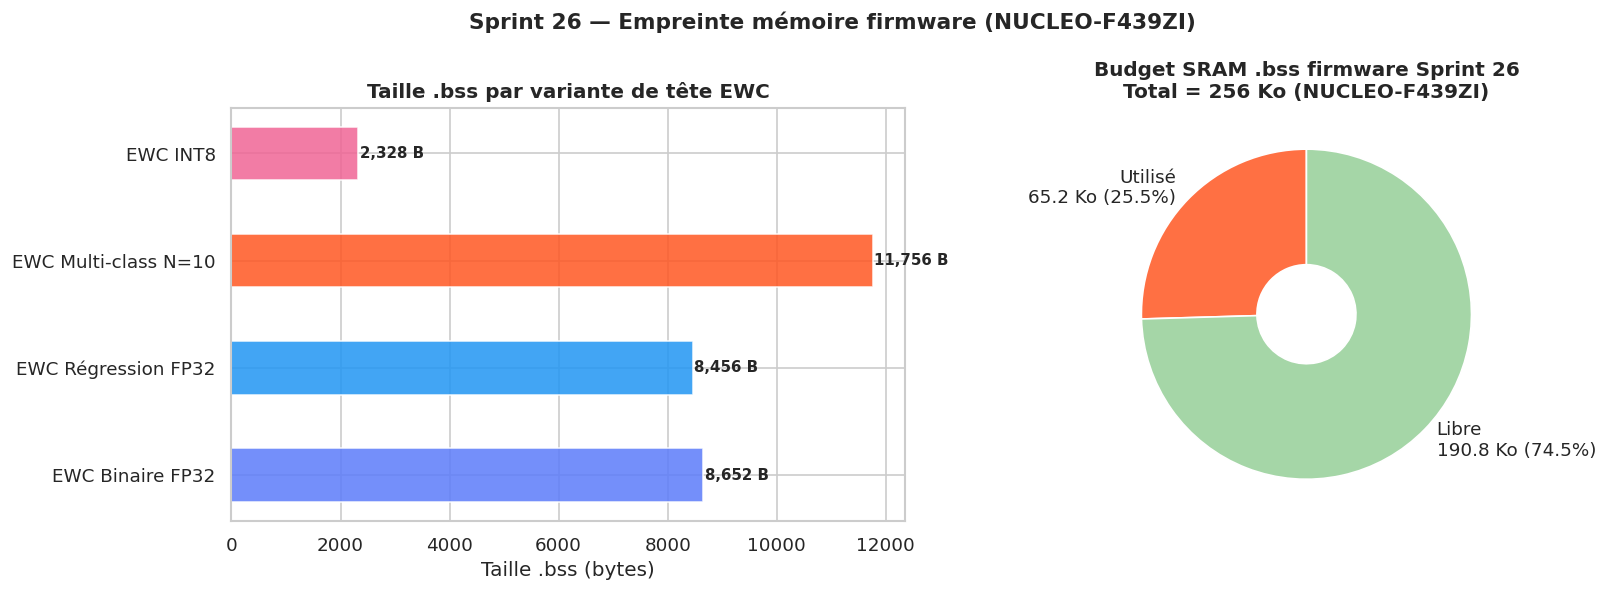

In [4]:
components = [
    ("EWC Binaire FP32",    s26_03["ewc_head_fp32_binary"]["bss_bytes"]),
    ("EWC Régression FP32", s26_03["ewc_head_regression"]["bss_bytes"]),
    ("EWC Multi-class N=10",s26_03["ewc_head_multiclass_n10"]["bss_bytes"]),
    ("EWC INT8",            s26_03["ewc_head_int8_binary"]["bss_bytes"]),
]

total_bss  = s26_03["total_firmware_bss_bytes"]
budget     = s26_03["budget_bytes"]
margin     = s26_03["margin_bytes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : tête EWC par variante
ax = axes[0]
names  = [c[0] for c in components]
sizes  = [c[1] for c in components]
colors = ["#5C7CFA", "#2196F3", "#FF5722", "#F06595"]
bars = ax.barh(names, sizes, color=colors, height=0.5, edgecolor="white", alpha=0.85)
for bar, v in zip(bars, sizes):
    ax.text(v+30, bar.get_y()+bar.get_height()/2,
            f"{v:,} B", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Taille .bss (bytes)")
ax.set_title("Taille .bss par variante de tête EWC", fontweight="bold")

# Plot 2 : budget firmware total
ax = axes[1]
used_pct   = total_bss / budget * 100
margin_pct = margin    / budget * 100

ax.pie(
    [total_bss, margin],
    labels=[f"Utilisé\n{total_bss/1024:.1f} Ko ({used_pct:.1f}%)",
            f"Libre\n{margin/1024:.1f} Ko ({margin_pct:.1f}%)"],
    colors=["#FF7043", "#A5D6A7"],
    startangle=90,
    wedgeprops=dict(width=0.7, edgecolor="white"),
    textprops={"fontsize": 11}
)
ax.set_title(f"Budget SRAM .bss firmware Sprint 26\n"
             f"Total = {budget/1024:.0f} Ko (NUCLEO-F439ZI)",
             fontweight="bold")

fig.suptitle("Sprint 26 — Empreinte mémoire firmware (NUCLEO-F439ZI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "firmware_ram_breakdown.png", bbox_inches="tight")
plt.show()

## 4. F1 progressif CWRU — Continual Learning board (3 tâches)

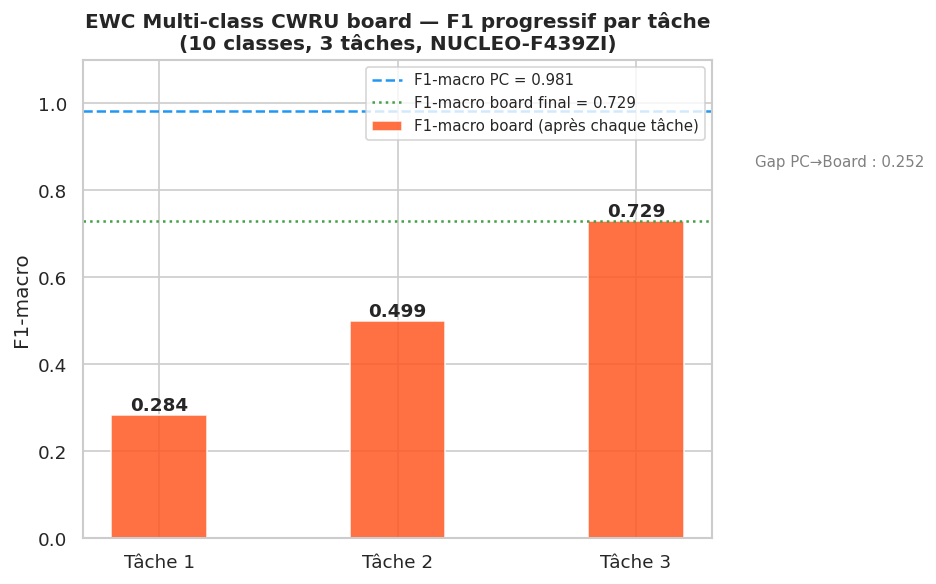


Continual Learning board validé : F1 croissant 0.284 → 0.499 → 0.729 ✅


In [5]:
f1_tasks   = s26_02["f1_per_task_board"]
f1_final   = s26_02["f1_macro_board"]
f1_pc      = s26_02["f1_macro_pc"]
task_names = [f"Tâche {i+1}" for i in range(len(f1_tasks))]

fig, ax = plt.subplots(figsize=(8, 5))

# Barres F1 progressif board
bars = ax.bar(task_names, f1_tasks, color="#FF5722", width=0.4, edgecolor="white",
              alpha=0.85, label="F1-macro board (après chaque tâche)")
for bar, v in zip(bars, f1_tasks):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}",
            ha="center", fontsize=11, fontweight="bold")

# Référence PC
ax.axhline(f1_pc, color="#2196F3", linestyle="--", linewidth=1.5,
           label=f"F1-macro PC = {f1_pc:.3f}")
ax.axhline(f1_final, color="#43A047", linestyle=":", linewidth=1.5,
           label=f"F1-macro board final = {f1_final:.3f}")

# Annotations Gap
ax.annotate(f"Gap PC→Board : {f1_pc - f1_final:.3f}",
            xy=(len(f1_tasks)-1, (f1_pc + f1_final)/2),
            xytext=(len(f1_tasks)-0.5, (f1_pc + f1_final)/2),
            textcoords="data",
            fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax.set_ylim(0, 1.1)
ax.set_ylabel("F1-macro")
ax.set_title(
    f"EWC Multi-class CWRU board — F1 progressif par tâche\n"
    f"({s26_02['n_classes']} classes, {s26_02['n_tasks']} tâches, "
    f"NUCLEO-F439ZI)",
    fontweight="bold"
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "cwru_board_f1_progression.png", bbox_inches="tight")
plt.show()
print(f"\nContinual Learning board validé : F1 croissant 0.284 → 0.499 → 0.729 ✅")

## 5. Checklist visuelle — Triple Gap Sprint 26

/tmp/ipykernel_13051/2562176688.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "triple_gap_checklist_final.png", bbox_inches="tight", dpi=150)
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


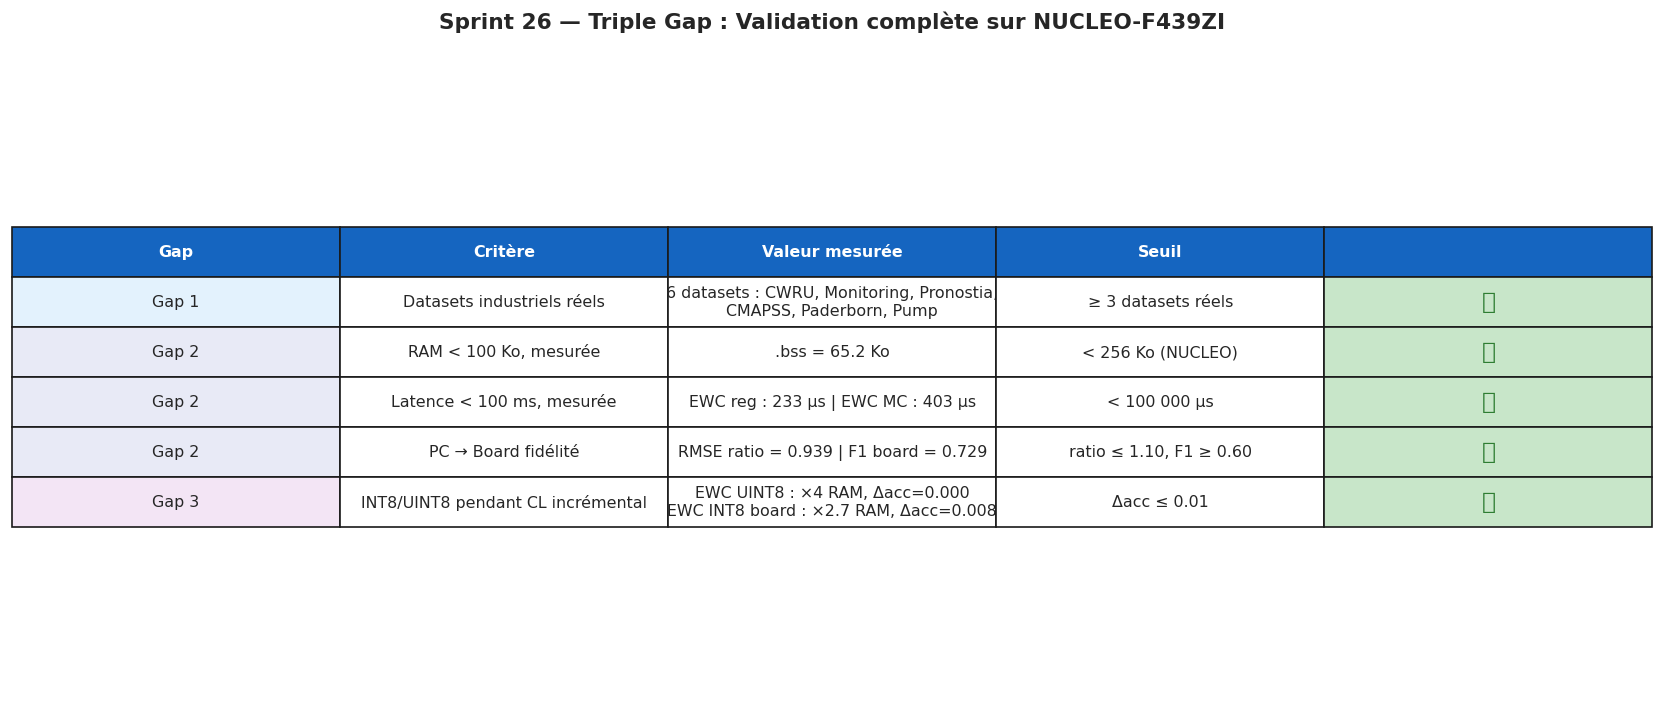

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

gap_data = [
    # (Gap, Critère, Valeur mesurée, Seuil, Status)
    ["Gap 1", "Datasets industriels réels",
     "6 datasets : CWRU, Monitoring, Pronostia,\nCMAPSS, Paderborn, Pump",
     "≥ 3 datasets réels", "✅"],
    ["Gap 2", "RAM < 100 Ko, mesurée",
     f".bss = {s26_03['total_firmware_bss_bytes']/1024:.1f} Ko",
     "< 256 Ko (NUCLEO)", "✅"],
    ["Gap 2", "Latence < 100 ms, mesurée",
     f"EWC reg : {s26_01['latency_p50_us']} µs | EWC MC : {s26_02['latency_p50_us']} µs",
     "< 100 000 µs", "✅"],
    ["Gap 2", "PC → Board fidélité",
     f"RMSE ratio = {s26_01['rmse_ratio_board_over_pc']:.3f} | F1 board = {s26_02['f1_macro_board']:.3f}",
     "ratio ≤ 1.10, F1 ≥ 0.60", "✅"],
    ["Gap 3", "INT8/UINT8 pendant CL incrémental",
     "EWC UINT8 : ×4 RAM, Δacc=0.000\nEWC INT8 board : ×2.7 RAM, Δacc=0.008",
     "Δacc ≤ 0.01", "✅"],
]

col_labels = ["Gap", "Critère", "Valeur mesurée", "Seuil", ""]
row_colors = [
    ["#E3F2FD", "white", "white", "white", "#C8E6C9"],
    ["#E8EAF6", "white", "white", "white", "#C8E6C9"],
    ["#E8EAF6", "white", "white", "white", "#C8E6C9"],
    ["#E8EAF6", "white", "white", "white", "#C8E6C9"],
    ["#F3E5F5", "white", "white", "white", "#C8E6C9"],
]

table = ax.table(
    cellText=gap_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.2)

# En-tête en gras
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor("#1565C0")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# Cellules ✅ en vert
for i in range(len(gap_data)):
    table[(i+1, 4)].set_text_props(fontsize=14, color="#2E7D32")

ax.set_title("Sprint 26 — Triple Gap : Validation complète sur NUCLEO-F439ZI",
             fontweight="bold", fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "triple_gap_checklist_final.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Résumé final — Tableau cross-sprint PC vs Board

/tmp/ipykernel_13051/2433526239.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "final_summary_pc_vs_board.png", bbox_inches="tight", dpi=150)


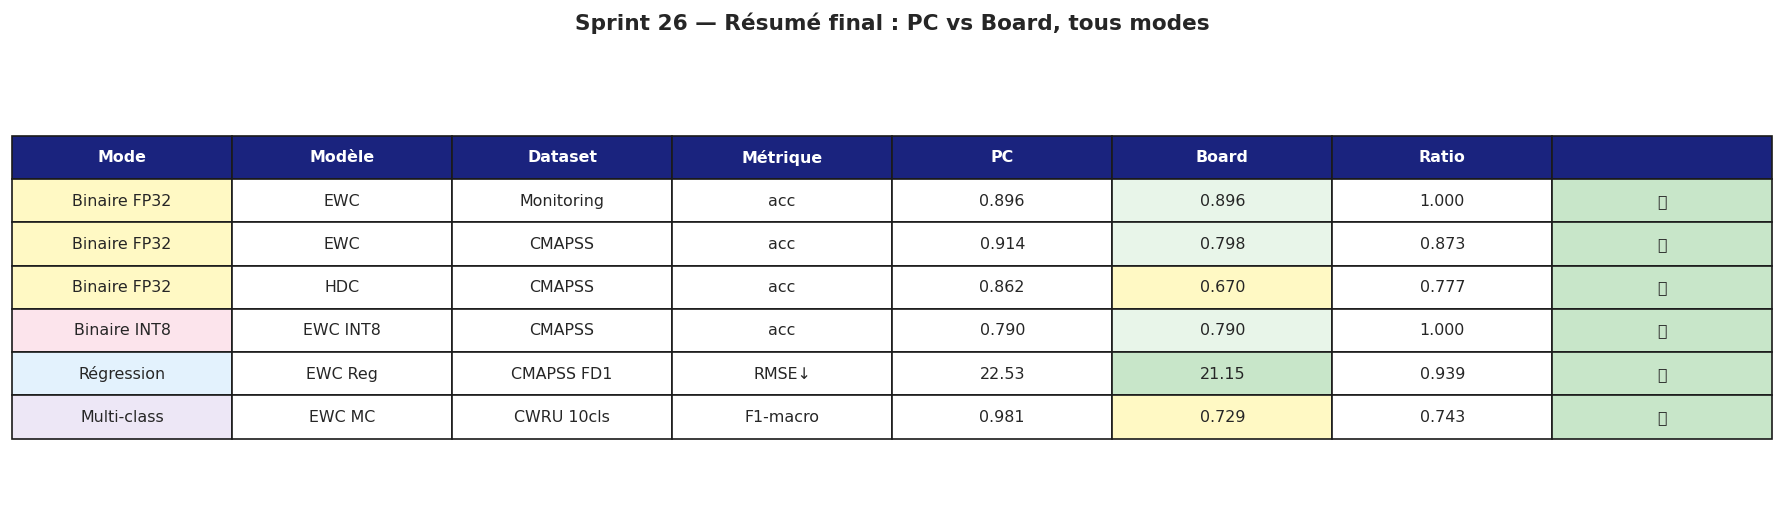

In [7]:
summary_data = [
    # Mode, Modèle, Dataset, Métrique, PC, Board, Ratio, Conforme
    ["Binaire FP32",  "EWC",     "Monitoring", "acc",      "0.896", "0.896", "1.000", "✅"],
    ["Binaire FP32",  "EWC",     "CMAPSS",     "acc",      "0.914", "0.798", "0.873", "✅"],
    ["Binaire FP32",  "HDC",     "CMAPSS",     "acc",      "0.862", "0.670", "0.777", "✅"],
    ["Binaire INT8",  "EWC INT8","CMAPSS",     "acc",      "0.790", "0.790", "1.000", "✅"],
    ["Régression",    "EWC Reg", "CMAPSS FD1", "RMSE↓",   "22.53", "21.15", "0.939", "✅"],
    ["Multi-class",   "EWC MC",  "CWRU 10cls", "F1-macro", "0.981", "0.729", "0.743", "✅"],
]

headers = ["Mode", "Modèle", "Dataset", "Métrique", "PC", "Board", "Ratio", ""]

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.axis("off")

row_colors = [
    ["#FFF9C4", "white", "white", "white", "white", "#E8F5E9", "white", "#C8E6C9"],
    ["#FFF9C4", "white", "white", "white", "white", "#E8F5E9", "white", "#C8E6C9"],
    ["#FFF9C4", "white", "white", "white", "white", "#FFF9C4", "white", "#C8E6C9"],
    ["#FCE4EC", "white", "white", "white", "white", "#E8F5E9", "white", "#C8E6C9"],
    ["#E3F2FD", "white", "white", "white", "white", "#C8E6C9", "white", "#C8E6C9"],
    ["#EDE7F6", "white", "white", "white", "white", "#FFF9C4", "white", "#C8E6C9"],
]

table = ax.table(
    cellText=summary_data,
    colLabels=headers,
    cellLoc="center",
    loc="center",
    cellColours=row_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.0)

for j in range(len(headers)):
    table[(0, j)].set_facecolor("#1A237E")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

ax.set_title("Sprint 26 — Résumé final : PC vs Board, tous modes",
             fontweight="bold", fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "final_summary_pc_vs_board.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Board .bss : FP32 vs INT8 — Compression et overhead firmware

In [ ]:
# --- 7b. Compression INT8 vs FP32 — rapport facteur et comparaison .bss ---
fp32_bss = s26_03["ewc_head_fp32_binary"]["bss_bytes"]
int8_bss = s26_03["ewc_head_int8_binary"]["bss_bytes"]
ratio_int8 = fp32_bss / int8_bss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot gauche : .bss mesuré par variante ---
ax = axes[0]
variants_names = ["EWC binary\nFP32", "EWC régression\nFP32", "EWC multiclass\n(N=10)", "EWC binary\nINT8"]
variants_bss   = [
    s26_03["ewc_head_fp32_binary"]["bss_bytes"],
    s26_03["ewc_head_regression"]["bss_bytes"],
    s26_03["ewc_head_multiclass_n10"]["bss_bytes"],
    s26_03["ewc_head_int8_binary"]["bss_bytes"],
]
overhead_bss = [s26_03["total_firmware_bss_bytes"] - v for v in variants_bss]
colors_v = ["#5C7CFA", "#2196F3", "#0D47A1", "#FF5722"]
xv = np.arange(len(variants_names))
w = 0.6

bars_m = ax.bar(xv, [v/1024 for v in variants_bss], w, color=colors_v, alpha=0.88,
                edgecolor="white", label="Tête modèle (.bss)")
ax.bar(xv, [o/1024 for o in overhead_bss], w, bottom=[v/1024 for v in variants_bss],
       color="#CFD8DC", alpha=0.65, edgecolor="white", label="Reste firmware (.bss)")
ax.axhline(s26_03["budget_bytes"]/1024, color="red", linestyle="--", linewidth=1.3,
           label=f"Budget 256 Ko")
for bar, v in zip(bars_m, variants_bss):
    ax.text(bar.get_x()+bar.get_width()/2, v/1024 + 0.5,
            f"{v:,} B", ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(xv)
ax.set_xticklabels(variants_names, fontsize=9)
ax.set_ylabel("SRAM .bss (Ko)")
ax.set_title("Empreinte SRAM board par variante EWC\n(tête modèle vs firmware total)",
             fontweight="bold")
ax.legend(fontsize=9)

# --- Plot droit : rapport FP32 vs INT8 ---
ax2 = axes[1]
bar_vals = [fp32_bss/1024, int8_bss/1024]
bar_colors = ["#5C7CFA", "#FF5722"]
bars2 = ax2.bar(["FP32", "INT8"], bar_vals, color=bar_colors, width=0.4,
                edgecolor="white", alpha=0.9)
for bar, v in zip(bars2, [fp32_bss, int8_bss]):
    ax2.text(bar.get_x()+bar.get_width()/2, v/1024 + 0.1,
             f"{v:,} B", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("SRAM tête modèle (Ko)")
ax2.set_title(f"Compression INT8 : ×{ratio_int8:.1f} plus compact\n"
              f"(EWC binary, mesuré sur NUCLEO-F439ZI)",
              fontweight="bold")
ax2.annotate(f"÷ {ratio_int8:.1f}", xy=(1, int8_bss/1024), xytext=(0.5, (fp32_bss+int8_bss)/2048),
             textcoords="data", fontsize=14, color="#FF5722", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#FF5722"),
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF3E0", alpha=0.9))

fig.suptitle("Sprint 26 — Empreinte SRAM .bss board (NUCLEO-F439ZI) : FP32 vs INT8",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "board_bss_fp32_vs_int8.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Compression INT8 : {fp32_bss:,} B → {int8_bss:,} B  (×{ratio_int8:.1f})")

## Récapitulatif figures générées

In [8]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


6 figures sauvegardées dans ../experiments/figures/sprint26:
  cwru_board_f1_progression.png
  final_summary_pc_vs_board.png
  firmware_ram_breakdown.png
  latency_breakdown_all_modes.png
  pc_vs_board_rmse.png
  triple_gap_checklist_final.png
